Quick Start
===========

This tutorial walks through the basic workflow for building a 3D galaxy morphology model with Gal3D.

This page is generated from a Jupyter notebook, which you can download using the link in the upper-right corner.

Extracting the Data
-------------------

We use the [AnastrisTNG](https://github.com/wx-ys/AnastrisTNG) library to extract the positions (`pos`) and masses (`mass`) of stellar particles for a galaxy in the TNG50-1 simulation.

These data are used in the 3D modeling example below.

In [1]:
import numpy as np
from AnastrisTNG import TNGsimulation

path = '/home/yxi/Simulation/sims/TNG50-1/output'
snap =99
snapshot = TNGsimulation.Snapshot(path,snap)

ID = 485056
sub = snapshot.load_particle(ID,order='star')
sub.physical_units()
coor_trans = sub.face_on(alignwith='star',rmax=2*sub.re)

pos = sub.s['pos']
mass = sub.s['mass']

```{note}
To demonstrate the Gal3D workflow, we use a galaxy extracted from TNG50-1. To apply the same workflow to other data sets, simply replace the particle positions (`pos`) and masses (`mass`). Here, `pos` should have shape `(N, 3)`, and `mass` should have shape `(N,)`.
```

Data Initialization
-------------------

```{note}
:class: margin
{py:meth}`Gal3DAnalyzer.analyze <gal3d.analyzer.Gal3DAnalyzer.analyze>` automates several steps, including {ref}`particle initialization <particle-initialization>`, {ref}`density-field construction <density-field>`, {ref}`shape setup <shape-setting>`, and {ref}`optimizer configuration <optimization>`. If you want finer control over each step, see {ref}`Step-by-Step Workflow <step_by_step>`.
```
Pass the particle positions (``pos``) and masses (``mass``) to the {py:meth}`Gal3DAnalyzer.analyze <gal3d.analyzer.Gal3DAnalyzer.analyze>` to initialize the 3D data.

- ``recenter`` controls whether the particles are recentered before analysis.
- ``inner_frac`` sets the inner boundary at the radius where the density falls to 90% of the central density.
- ``outer`` and ``outer_mode`` control how the outer boundary is defined.

In [2]:
from gal3d.analyzer import Gal3DAnalyzer

gal = Gal3DAnalyzer.analyze(
    pos, mass, recenter=True, inner_frac=0.9,
    outer = 35, outer_mode = "dist")

<gal3d.particle.global_calculator> | INFO | Recentered positions by subtracting center: [-0.00168869  0.00015073  0.00111993]
<gal3d.analyzer> | INFO | Built spherical field with 1024 rays
<gal3d.analyzer> | INFO | Set inner value to 2.196e+10
<gal3d.analyzer> | INFO | Set outer dist to 3.500e+01
<gal3d.preprocessing.spherical_field.spherical_vector> | INFO | 1024 points on the sphere by fibonacci method have the uniformity of 99.688
<gal3d.field.SphField> | INFO | Build ray vector: 0.12 sec
from <field.py> line: 111 
  >>>  | WARNING | The axial ratio of the inner boundary shape is quite extreme. Consider limiting the particles or refining the boundary.
<gal3d.field.SphField> | INFO | Build field boundary: 1.08 sec
<gal3d.field.SphField> | INFO | Build profile sample: 1.00 sec
<gal3d.field.SphField> | INFO | Build profile interpolator: 0.74 sec
<gal3d.field.SphField> | INFO | Set isodensity sphere: 1.02 sec
<gal3d.field.SphField> | INFO | Build isodensity profile: 1.74 sec
<gal3d.anal

Fitting the Model
-----------------

After initialization, the next step is to fit a model to the 3D galaxy structure.

We use {py:meth}`Gal3DAnalyzer.fit <gal3d.analyzer.Gal3DAnalyzer.fit>` to fit a set of nested ellipsoids to the particle distribution. Setting `num_step=300` generates 300 nested ellipsoids. The default value is `200`.

In [4]:
res_ellipsoid_s = gal.fit(num_step=300)

<gal3d.analyzer> | INFO | Using workflow: EllipsoidFitWorkflow
from <fit_workflow.py> line: 146    
  >>>  | WARNING | PoorUniformityError: skipped 9 radii from 0.3457 to 0.3911
Fitting radii: 100%|██████████| 300/300 [00:30<00:00,  9.74it/s]


You may see a `PoorUniformityError` warning. This means that the sampling points are not sufficiently uniform at certain radii, which may reduce the accuracy of the fit. Those radii are therefore skipped.

Fitting Results
---------------

```{seealso}
:class: margin
For more information about the {py:class}`ModelResult <gal3d.optimization.result.ModelResult>` class, see the {ref}`Fitting and Optimization <optimization>` documentation.
```
After fitting, ``res_ellipsoid_s`` contains the parameter values for all nested ellipsoids. It is a {py:class}`ModelResult <gal3d.optimization.result.ModelResult>` object that stores the fitted model, model parameters, goodness-of-fit diagnostics, and related quantities.



Use ``res_ellipsoid_s.keys()`` to inspect the main parameter keys.

In [5]:
res_ellipsoid_s.keys()

dict_keys(['x', 'y', 'z', 'ang1', 'ang2', 'ang3', 'a', 'eps_ab', 'eps_bc', 'sa', 'sb', 'sc'])


Use `res_ellipsoid_s.available_keys()` to view all available keys, including both parameter keys and other related quantities.

In [6]:
res_ellipsoid_s.available_keys()

dict_keys(['x', 'y', 'z', 'ang1', 'ang2', 'ang3', 'a', 'eps_ab', 'eps_bc', 'sa', 'sb', 'sc', 'pos', 'angle', 'rot_matrix', 'x_axis_angle', 'z_axis_angle', 'x_axis_angle_err', 'z_axis_angle_err', 'eps_ac', 'T', 'b', 'c', 'eps_ac_err', 'T_err', 'eps_ac_s', 'parameter', 'data'])

You can also display `res_ellipsoid_s` directly as a table.

In [7]:
res_ellipsoid_s

ModelResult | num=291 | ShiftEuler | Ellipsoid_S | isodensity_curve_dcall
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  #   cost             x             y            z          ang1          ang2          ang3             a       eps_ab       eps_bc           sa           sb           sc
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  0  0.076  -0.033±0.007   0.040±0.005  0.014±0.002  -1.107±0.036  -0.021±0.012  -0.014±0.021   0.415±0.010  0.402±0.027  0.575±0.016  1.826±0.261  1.741±0.261  0.325±0.075
  1  0.071  -0.039±0.006   0.025±0.004  0.012±0.002  -1.038±0.031  -0.023±0.011  -0.004±0.020   0.422±0.010  0.419±0.024  0.562±0.015  1.746±0.225  1.710±0.236  0.319±0.068
  2  0.055  -0.041±0.006   0.001±0.004  0.010±0.001  -0.992±0.026  -0.027±0.009   0.012±0.017   0.451±0.009  0.437±0.019  0.540±0.013  1.399±0.160  1.500±0.172  0.413±0.069
  3  0.052  -0.042±0.006   0.003±0.003  0.008±0.001  -0.989±0.024  -0.022±0.009   0.009±0.017   0.466±0.009  0.445±0.018  0.536±0.012  1.339±0.146  1.425±0.156  0.426±0.068
  4  0.051  -0.042±0.006   0.003±0.003  0.008±0.001  -0.989±0.024  -0.020±0.009   0.010±0.017   0.465±0.009  0.444±0.018  0.536±0.012  1.349±0.148  1.431±0.158  0.437±0.070
 ⋮     ⋮         ⋮             ⋮             ⋮            ⋮             ⋮             ⋮             ⋮             ⋮            ⋮            ⋮            ⋮            ⋮     
286  0.004   1.268±0.170  -0.685±0.229  0.278±0.068   1.350±0.156  -0.100±0.007  -0.016±0.017  30.932±0.157  0.029±0.009  0.416±0.005  0.972±0.042  1.001±0.043  1.577±0.061
287  0.004   0.956±0.161  -0.738±0.166  0.351±0.069   1.291±0.119  -0.106±0.007  -0.004±0.015  31.773±0.162  0.038±0.009  0.403±0.005  0.957±0.041  0.979±0.041  1.568±0.060
288  0.004   0.837±0.164  -0.744±0.159  0.319±0.070   1.258±0.124  -0.103±0.007   0.006±0.015  32.374±0.162  0.035±0.008  0.393±0.005  0.903±0.038  1.041±0.041  1.534±0.057
289  0.004   0.792±0.156  -0.654±0.152  0.310±0.070   1.295±0.119  -0.107±0.007   0.014±0.015  32.613±0.160  0.036±0.008  0.388±0.005  0.907±0.038  1.058±0.042  1.532±0.056
290  0.004   0.725±0.169  -0.686±0.158  0.313±0.072   1.354±0.138  -0.112±0.009   0.028±0.017  32.710±0.162  0.032±0.009  0.380±0.005  0.861±0.037  1.143±0.044  1.532±0.057
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
[291 rows × 12 parameters]  —  head(n) / tail(n) to select rows

You can access the nth ellipsoid with `res_ellipsoid_s[n]` and inspect its detailed properties.

In [8]:
res_ellipsoid_s[0]

<Structure3D|
   Coord : <ShiftEuler|: (
        x     = -0.033 ± 0.007  [-0.040, 0.040]
        y     = 0.040 ± 0.005  [-0.040, 0.040]
        z     = 0.014 ± 0.002  [-0.040, 0.040]
        ang1  = -1.107 ± 0.036  [-3.142, 3.142]
        ang2  = -0.021 ± 0.012  [-1.571, 1.571]
        ang3  = -0.014 ± 0.021  [-3.142, 3.142]
      )|>
   Geom  : <Ellipsoid_S|: (
        a       = 0.415 ± 0.010  [0.278, 0.516]
        eps_ab  = 0.402 ± 0.027  [0.001, 0.999]
        eps_bc  = 0.575 ± 0.016  [0.001, 0.999]
        sa      = 1.826 ± 0.261  [0.200, 2.000]
        sb      = 1.741 ± 0.261  [0.200, 2.000]
        sc      = 0.325 ± 0.075  [0.200, 2.000]
      )|>
   Error : sums_dev_rscale / isodensity_curve_dcall
|>

You can also examine how the shape parameters vary with radius.

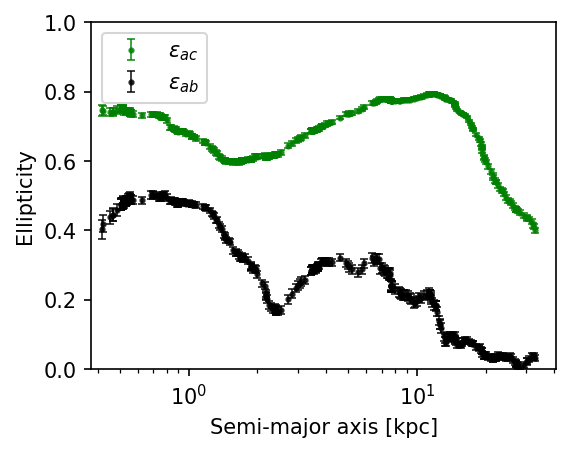

In [8]:
import matplotlib.pyplot as plt

fg, ax = plt.subplots(dpi=150,figsize=(4,3))

res_ellipsoid_s.errorbar("a","eps_ac",ax=ax,c='g',label=True)
res_ellipsoid_s.errorbar("a","eps_ab",ax=ax,c="k",label=True)
ax.legend()
ax.set_xscale("log")
ax.set_ylim(0,1)
ax.set_xlim(res_ellipsoid_s['a'].min()*0.9,)
ax.set_xlabel('Semi-major axis [kpc]')
ax.set_ylabel("Ellipticity")
plt.show()

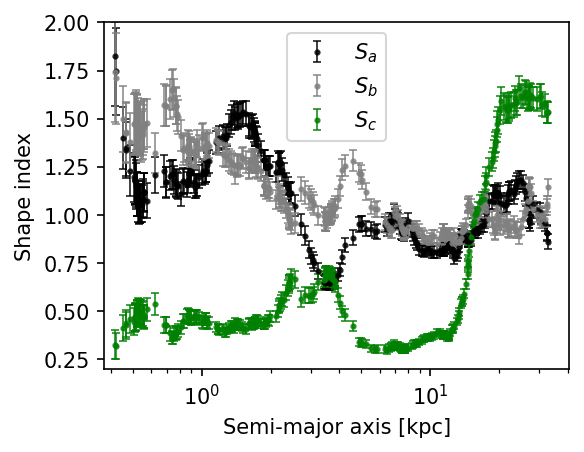

In [9]:
fg, ax = plt.subplots(dpi=150,figsize=(4,3))

res_ellipsoid_s.errorbar("a","sa",ax=ax,c='k',label=True)
res_ellipsoid_s.errorbar("a","sb",ax=ax,c="grey",label=True)
res_ellipsoid_s.errorbar("a","sc",ax=ax,c="g",label=True)
ax.legend()
ax.set_xscale("log")
ax.set_ylim(0.2,2)
ax.set_xlim(res_ellipsoid_s['a'].min()*0.9,)
ax.set_xscale('log')
ax.legend()
ax.set_xlabel('Semi-major axis [kpc]')
ax.set_ylabel("Shape index")
plt.show()

Result Analysis
---------------

After obtaining the fitting results, you can analyze them using the {py:class}`Characterizer <gal3d.characterization.characterizer.Characterizer>` class.

Use {py:obj}`Characterizer.available_plugins <gal3d.characterization.characterizer.Characterizer.available_plugins>` to list all available characterization plugins. For example, the {py:class}`Bar <gal3d.characterization.characterizer_plugins.galaxy_bar.Bar>` plugin can be used to measure the morphological properties of galactic bars.

In [10]:
from gal3d.characterization import Characterizer
Characterizer.available_plugins()

['Bar', 'Disk', 'Segment']

Use `Characterizer.get_plugin('Bar')` to obtain the Bar plugin and apply it to the fitted result:

In [11]:
bar = Characterizer.get_plugin('Bar')
bar(res_ellipsoid_s).measure(other_keys='eps_bc')

{'flag': 1,
 'eps_max': 0.5026474803055644,
 'R_max': 0.7867076344565652,
 'R_bar': 1.339494628579574,
 'R_max_eps_bc': 0.449113275811817,
 'R_bar_eps_bc': 0.3380900653437971}

`flag=1` indicates that a bar is detected. `R_bar` gives the semi-major-axis length of the bar.

Visualization
-------------

Gal3D also provides visualization tools for direct comparison between the model and the data.

The {py:class}`ModelProjector <gal3d.visualization.model_projector.ModelProjector>` plugin projects the 3D model onto a 2D plane, and {py:class}`ProjectorLineIntegration <gal3d.visualization.model_projector_plugins.projector_line_integration.ProjectorLineIntegration>` supports line-of-sight integrated projections.

The helper function {py:func}`show_image_model_residual <gal3d.visualization.data_model_residual.show_image_model_residual>` displays the projected data, the projected model, and their residuals side by side for easy comparison.

```{note}
:class: margin

To speed up the computation, you can increase the number of threads. Set this according to the number of CPU cores available on your machine; for example:

```python
from gal3d.configuration import config
config.general.number_of_threads = 4
```
```

<gal3d.visualization.ModelProjector> | INFO | Projector removed 23 steps with relatively large fit error
Integrating Profiles: 100%|██████████| 22500/22500 [00:01<00:00, 11419.55it/s]


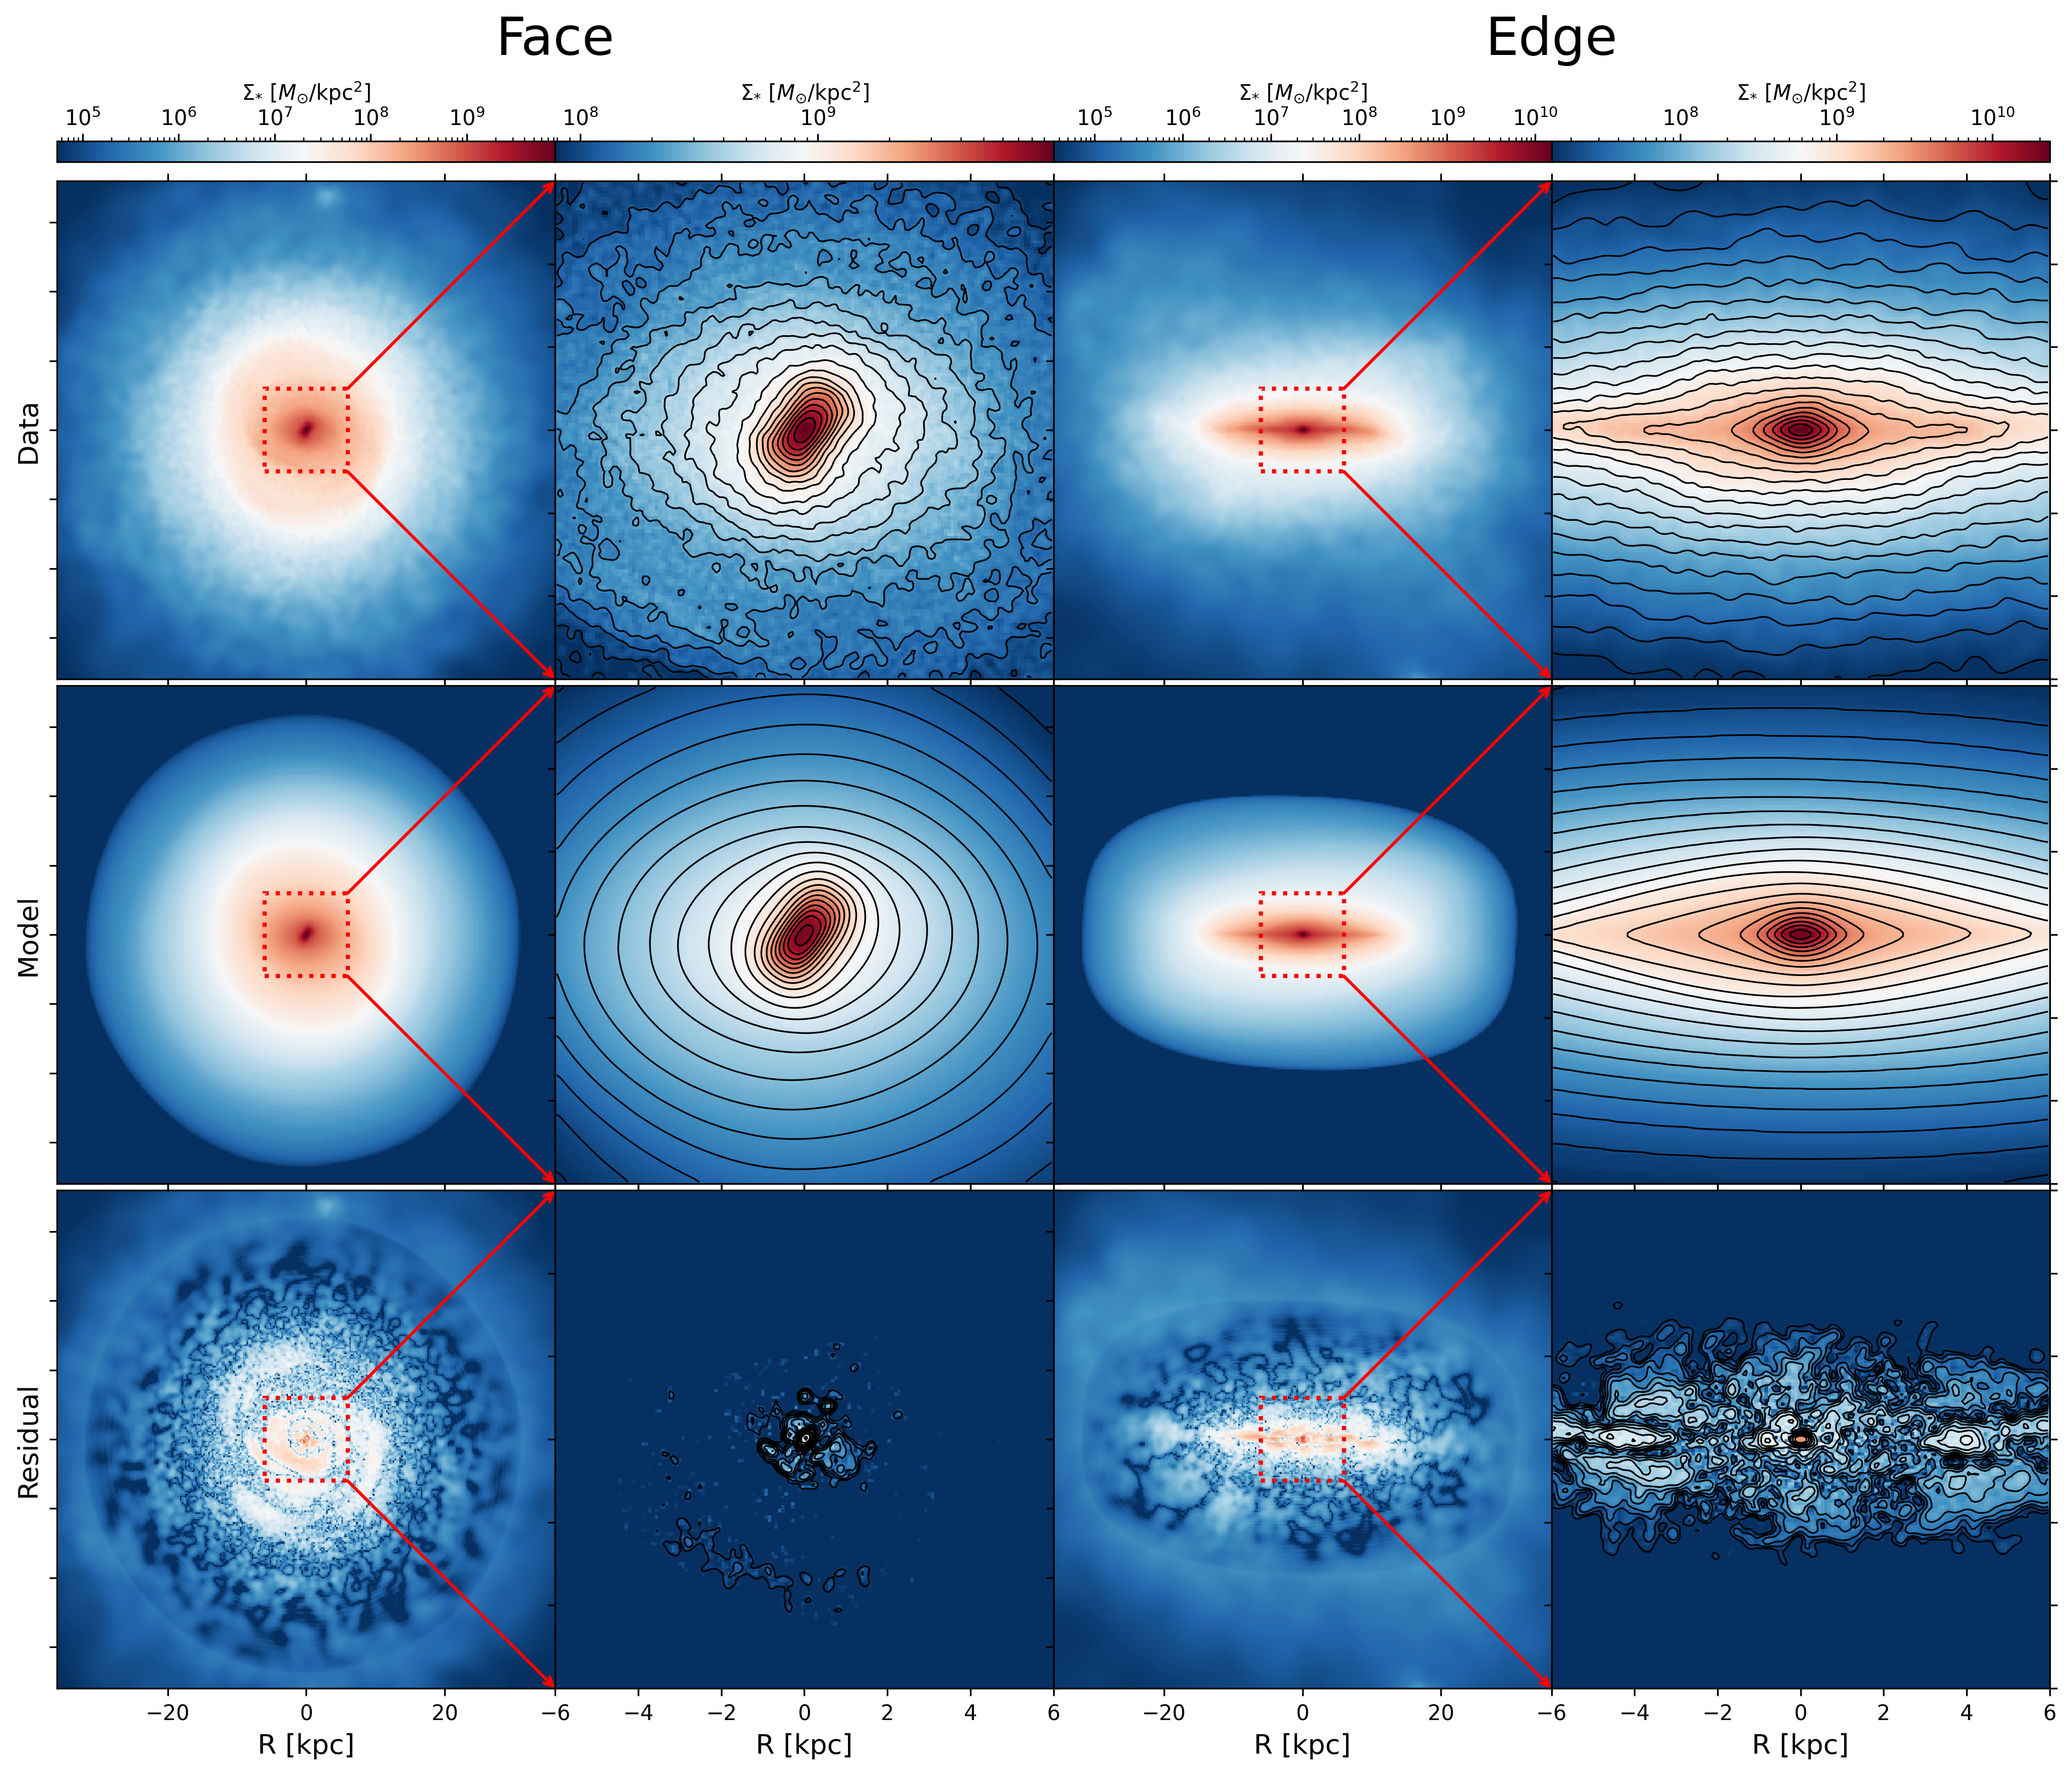

In [14]:
from gal3d.visualization import ModelProjector, show_image_model_residual

ellipsoid_s_model = ModelProjector.get_plugin('ProjectorLineIntegration')(res_ellipsoid_s)

box_lh_max =res_ellipsoid_s['a'][-1]*1.1
zoom_lh_max = 6
large_box_range = (-box_lh_max,box_lh_max)
zoom_range=(-zoom_lh_max,zoom_lh_max)
im = show_image_model_residual(gal.density_source,
                            ellipsoid_s_model,
                          large_box_x_range = large_box_range,
                          large_box_y_range= large_box_range,
                          zoom_x_range=zoom_range,
                          zoom_y_range=zoom_range,
                          depth_z_range=large_box_range,
                          cmap="RdBu_r",
                          nbins_large=300,
                          nbins_zoom=150,
                          nlevels_large=0,
                          nlevels_zoom=22)